In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv(
    "/content/ai4i2020.csv"
)

print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (10000, 14)


In [4]:
print(df.columns.tolist())

['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [6]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [7]:
missing_values = df.isnull().sum()

print("Missing values:")
print(
    missing_values[
        missing_values > 0
    ]
)

Missing values:
Series([], dtype: int64)


In [8]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [9]:
failure_count = (
    df["Machine failure"]
    .value_counts()
    .sort_index()
)

failure_count

,count
Machine failure,
0,9661
1,339


In [10]:
failure_percentage = (
    df["Machine failure"]
    .value_counts(
        normalize=True
    )
    .sort_index()
    * 100
)

failure_percentage

,proportion
Machine failure,
0,96.61
1,3.39


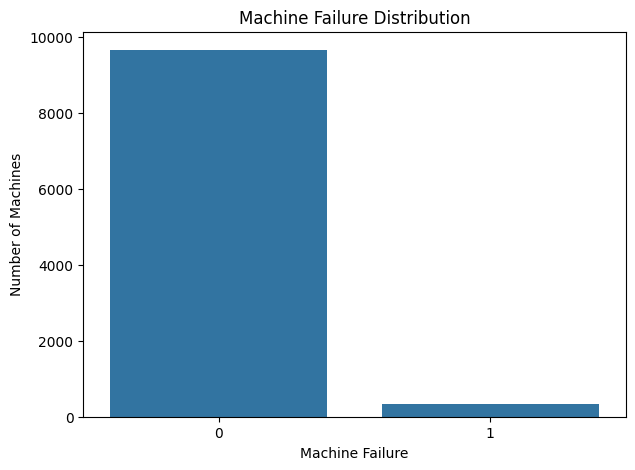

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Machine failure"
)

plt.title(
    "Machine Failure Distribution"
)

plt.xlabel("Machine Failure")
plt.ylabel("Number of Machines")

plt.show()

In [12]:
failure_by_type = (
    df.groupby("Type")["Machine failure"]
    .mean()
    .sort_values(
        ascending=False
    )
)

failure_by_type

,Machine failure
Type,
L,0.039167
M,0.027694
H,0.020937


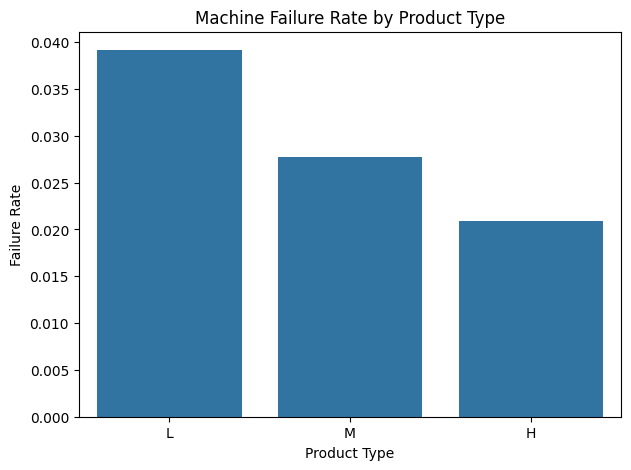

In [13]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=failure_by_type.index,
    y=failure_by_type.values
)

plt.title(
    "Machine Failure Rate by Product Type"
)

plt.xlabel("Product Type")
plt.ylabel("Failure Rate")

plt.show()

In [14]:
sensor_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Machine failure"
]

In [15]:
correlation = (
    df[sensor_features]
    .corr()["Machine failure"]
    .sort_values(
        ascending=False
    )
)

correlation

,Machine failure
Machine failure,1.000000
Torque [Nm],0.191321
Tool wear [min],0.105448
Air temperature [K],0.082556
Process temperature [K],0.035946
Rotational speed [rpm],-0.044188


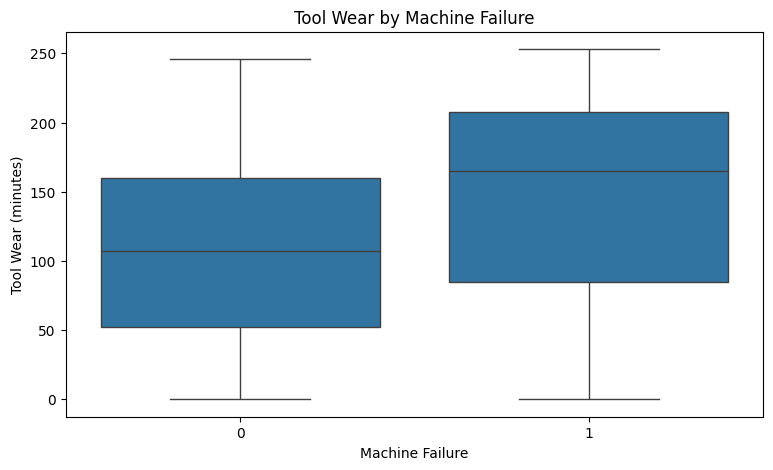

In [16]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Machine failure",
    y="Tool wear [min]"
)

plt.title(
    "Tool Wear by Machine Failure"
)

plt.xlabel("Machine Failure")
plt.ylabel("Tool Wear (minutes)")

plt.show()

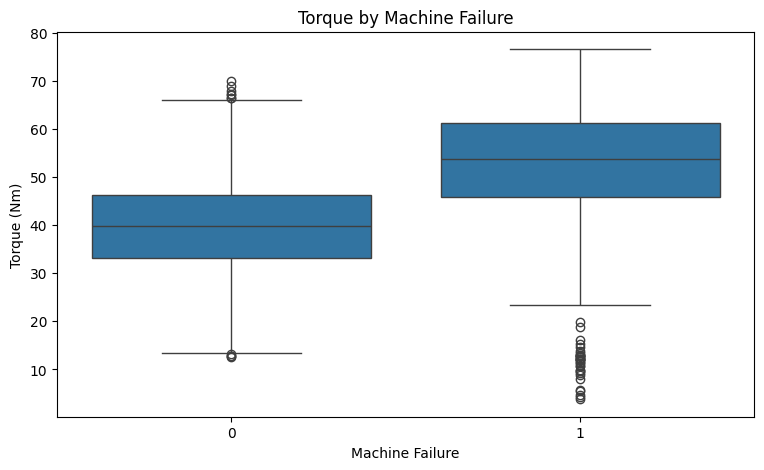

In [17]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Machine failure",
    y="Torque [Nm]"
)

plt.title(
    "Torque by Machine Failure"
)

plt.xlabel("Machine Failure")
plt.ylabel("Torque (Nm)")

plt.show()

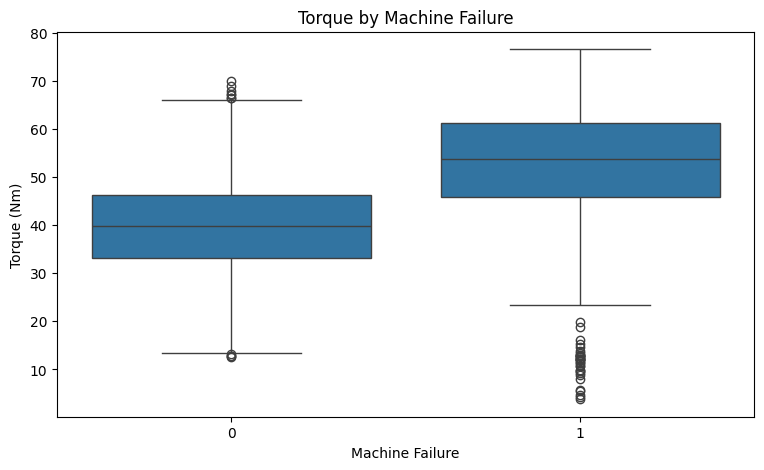

In [18]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Machine failure",
    y="Torque [Nm]"
)

plt.title(
    "Torque by Machine Failure"
)

plt.xlabel("Machine Failure")
plt.ylabel("Torque (Nm)")

plt.show()

In [19]:
df["Temperature_Difference"] = (
    df["Process temperature [K]"]
    - df["Air temperature [K]"]
)

In [20]:
df[
    [
        "Air temperature [K]",
        "Process temperature [K]",
        "Temperature_Difference"
    ]
].head()

,Air temperature [K],Process temperature [K],Temperature_Difference
0,298.1,308.6,10.5
1,298.2,308.7,10.5
2,298.1,308.5,10.4
3,298.2,308.6,10.4
4,298.2,308.7,10.5


In [21]:
df["Torque_Speed_Product"] = (
    df["Torque [Nm]"]
    *
    df["Rotational speed [rpm]"]
)

In [22]:
df[
    [
        "Torque [Nm]",
        "Rotational speed [rpm]",
        "Torque_Speed_Product"
    ]
].head()

,Torque [Nm],Rotational speed [rpm],Torque_Speed_Product
0,42.8,1551,66382.8
1,46.3,1408,65190.4
2,49.4,1498,74001.2
3,39.5,1433,56603.5
4,40.0,1408,56320.0


In [23]:
df_model = pd.get_dummies(
    df,
    columns=["Type"],
    drop_first=True,
    dtype=int
)

In [24]:
df_model.head()

,UDI,Product ID,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temperature_Difference,Torque_Speed_Product,Type_L,Type_M
0,1,M14860,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8,0,1
1,2,L47181,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4,1,0
2,3,L47182,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2,1,0
3,4,L47183,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5,1,0
4,5,L47184,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0,1,0


In [25]:
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature_Difference",
    "Torque_Speed_Product",
    "Type_L",
    "Type_M"
]

In [26]:
target = "Machine failure"

In [27]:
X = df_model[features].copy()
y = df_model[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 9)
y shape: (10000,)


In [28]:
X.columns = (
    X.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace(" ", "_", regex=False)
)

In [29]:
print(X.columns.tolist())

['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Temperature_Difference', 'Torque_Speed_Product', 'Type_L', 'Type_M']


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (8000, 9)
Testing : (2000, 9)


In [31]:
print("Training distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

Training distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Testing distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [33]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [34]:
y_pred_lr = lr_model.predict(
    X_test_scaled
)

y_prob_lr = lr_model.predict_proba(
    X_test_scaled
)[:, 1]

In [36]:
def evaluate_model(
    y_true,
    y_pred,
    y_prob
):
    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )

    pr_auc = average_precision_score(
        y_true,
        y_prob
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }

In [37]:
lr_results = evaluate_model(
    y_test,
    y_pred_lr,
    y_prob_lr
)

lr_results

{'Accuracy': 0.9675,
 'Precision': 0.5714285714285714,
 'Recall': 0.17647058823529413,
 'F1': 0.2696629213483146,
 'ROC-AUC': np.float64(0.9254962854707101),
 'PR-AUC': np.float64(0.46133755147735883)}

In [38]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.57      0.18      0.27        68

    accuracy                           0.97      2000
   macro avg       0.77      0.59      0.63      2000
weighted avg       0.96      0.97      0.96      2000



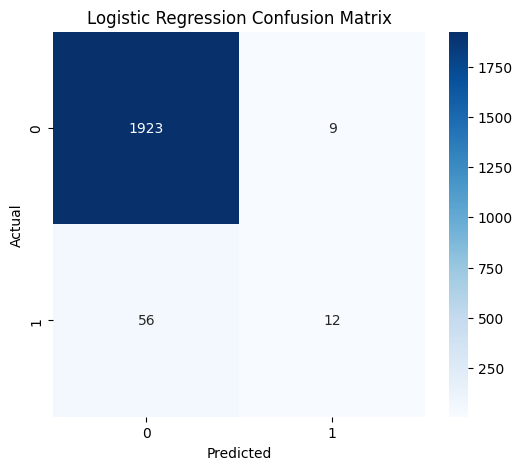

In [39]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [40]:
lr_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_balanced.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [41]:
y_pred_balanced = (
    lr_balanced.predict(
        X_test_scaled
    )
)

y_prob_balanced = (
    lr_balanced.predict_proba(
        X_test_scaled
    )[:, 1]
)

In [42]:
balanced_results = evaluate_model(
    y_test,
    y_pred_balanced,
    y_prob_balanced
)

balanced_results

{'Accuracy': 0.859,
 'Precision': 0.17771084337349397,
 'Recall': 0.8676470588235294,
 'F1': 0.295,
 'ROC-AUC': np.float64(0.9338920350748996),
 'PR-AUC': np.float64(0.46568882850155274)}

In [43]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=2, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [44]:
y_prob_rf = rf_model.predict_proba(
    X_test
)[:, 1]

y_pred_rf = (
    y_prob_rf >= 0.5
).astype(int)

In [45]:
rf_results = evaluate_model(
    y_test,
    y_pred_rf,
    y_prob_rf
)

rf_results

{'Accuracy': 0.991,
 'Precision': 0.9310344827586207,
 'Recall': 0.7941176470588235,
 'F1': 0.8571428571428571,
 'ROC-AUC': np.float64(0.9628166483984899),
 'PR-AUC': np.float64(0.8656206765477829)}

In [46]:
neg_count = (
    y_train == 0
).sum()

pos_count = (
    y_train == 1
).sum()

scale_pos_weight = (
    neg_count / pos_count
)

print(
    "Scale Pos Weight:",
    scale_pos_weight
)

Scale Pos Weight: 28.52029520295203


In [47]:
xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

In [48]:
xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [49]:
y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:, 1]

y_pred_xgb = (
    y_prob_xgb >= 0.5
).astype(int)

In [50]:
xgb_results = evaluate_model(
    y_test,
    y_pred_xgb,
    y_prob_xgb
)

xgb_results

{'Accuracy': 0.9875,
 'Precision': 0.8115942028985508,
 'Recall': 0.8235294117647058,
 'F1': 0.8175182481751825,
 'ROC-AUC': np.float64(0.9790296553403971),
 'PR-AUC': np.float64(0.8740993526774155)}

In [51]:
maintenance_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **lr_results
    },
    {
        "Model": "Balanced Logistic Regression",
        **balanced_results
    },
    {
        "Model": "Random Forest",
        **rf_results
    },
    {
        "Model": "XGBoost",
        **xgb_results
    }
])

maintenance_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.9675,0.571429,0.176471,0.269663,0.925496,0.461338
1,Balanced Logistic Regression,0.8590,0.177711,0.867647,0.295000,0.933892,0.465689
2,Random Forest,0.9910,0.931034,0.794118,0.857143,0.962817,0.865621
3,XGBoost,0.9875,0.811594,0.823529,0.817518,0.979030,0.874099


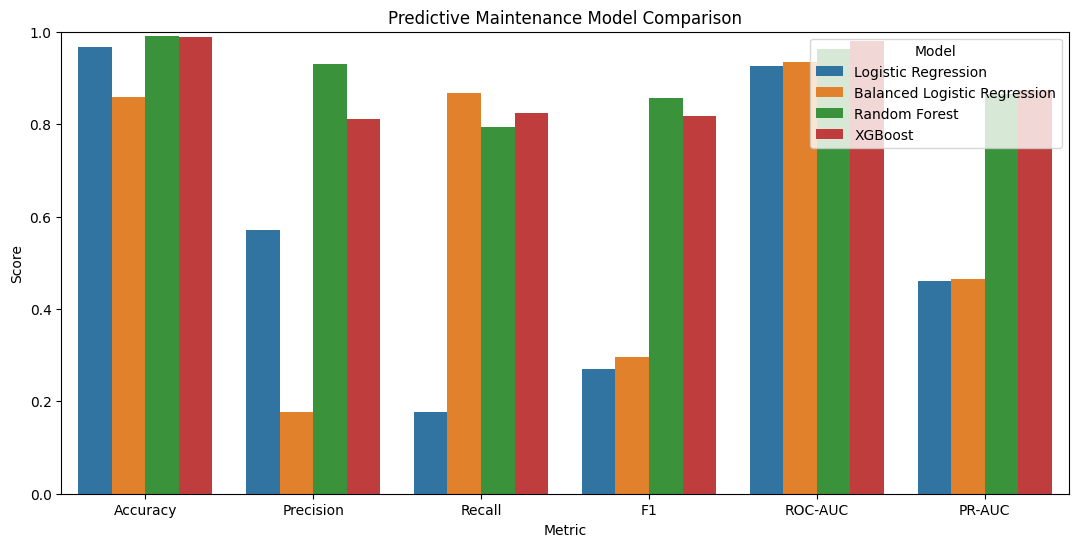

In [52]:
comparison_long = (
    maintenance_comparison
    .melt(
        id_vars="Model",
        var_name="Metric",
        value_name="Score"
    )
)

plt.figure(figsize=(13, 6))

sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.ylim(0, 1)

plt.title(
    "Predictive Maintenance Model Comparison"
)

plt.ylabel("Score")

plt.show()

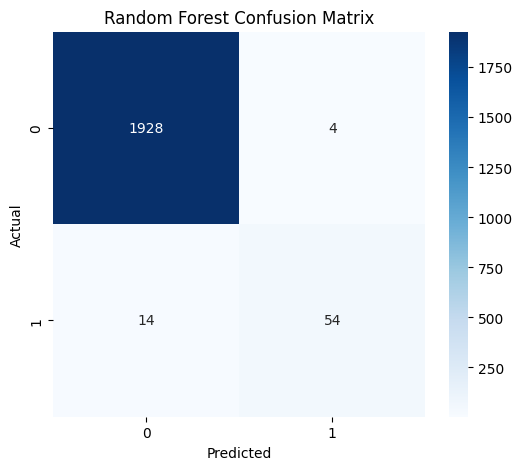

In [54]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

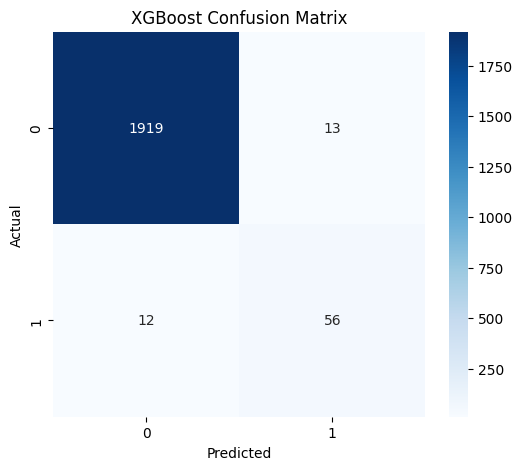

In [55]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "XGBoost Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [56]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

rf_importance

,Feature,Importance
2,Rotational_speed_rpm,0.225644
4,Tool_wear_min,0.208876
3,Torque_Nm,0.207965
6,Torque_Speed_Product,0.184665
5,Temperature_Difference,0.085205
0,Air_temperature_K,0.045908
1,Process_temperature_K,0.029750
7,Type_L,0.006672
8,Type_M,0.005316


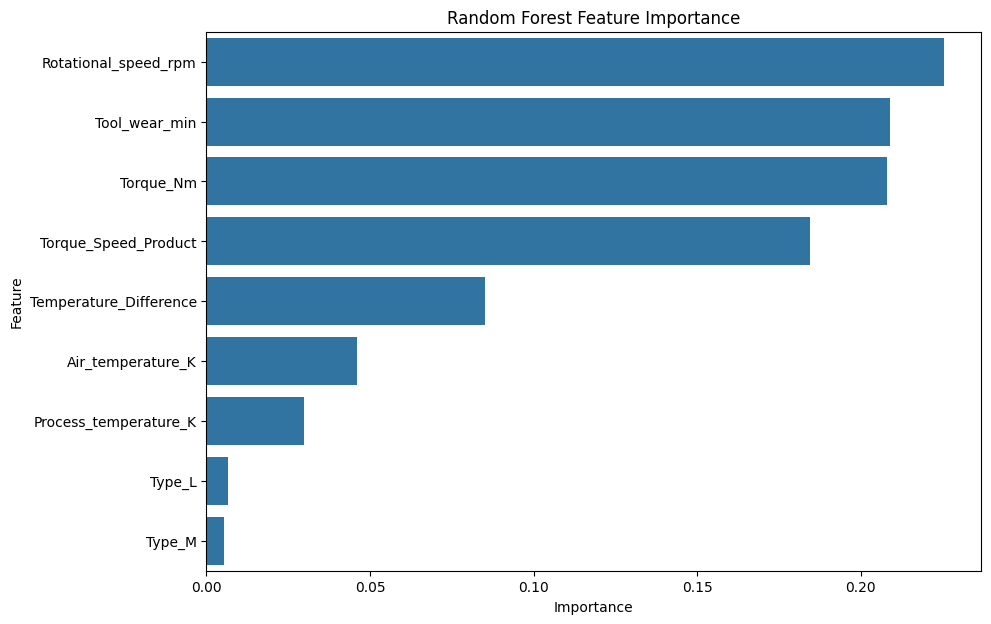

In [57]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [58]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

xgb_importance

,Feature,Importance
2,Rotational_speed_rpm,0.235739
3,Torque_Nm,0.192676
4,Tool_wear_min,0.168237
6,Torque_Speed_Product,0.166064
5,Temperature_Difference,0.090043
0,Air_temperature_K,0.039866
7,Type_L,0.038587
1,Process_temperature_K,0.038312
8,Type_M,0.030475


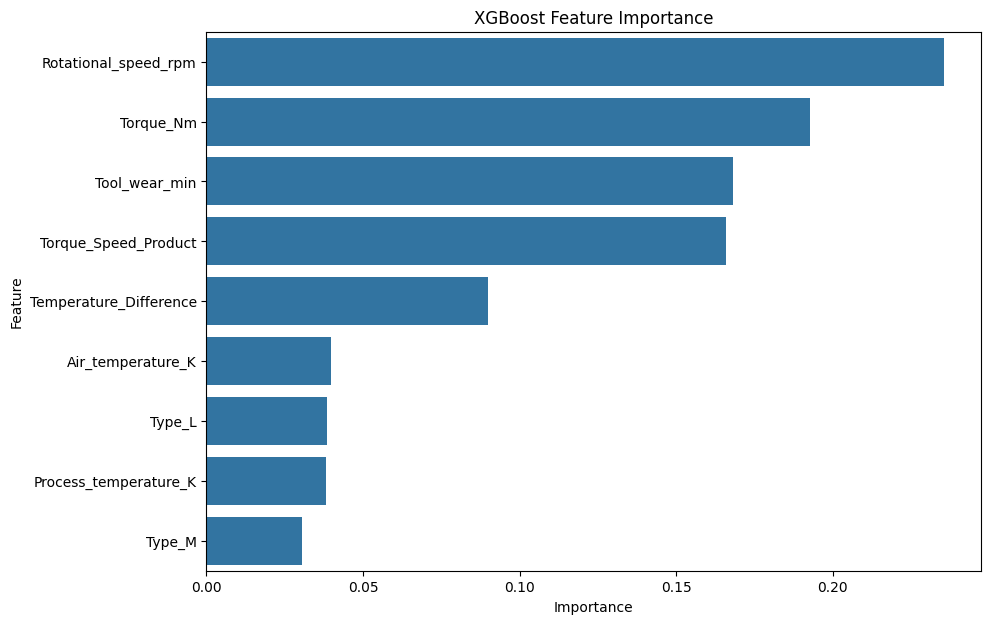

In [59]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=xgb_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "XGBoost Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [60]:
risk_df = X_test.copy()

risk_df["Actual"] = y_test.values

risk_df["FailureProbability"] = y_prob_rf

In [61]:
def failure_risk(probability):

    if probability >= 0.70:
        return "High Risk"

    elif probability >= 0.30:
        return "Medium Risk"

    else:
        return "Low Risk"

In [62]:
risk_df["RiskLevel"] = (
    risk_df["FailureProbability"]
    .apply(failure_risk)
)

In [63]:
risk_distribution = (
    risk_df["RiskLevel"]
    .value_counts()
)

risk_distribution

,count
RiskLevel,
Low Risk,1917
High Risk,43
Medium Risk,40


In [64]:
risk_profile = (
    risk_df
    .groupby("RiskLevel")
    .agg(
        machines=("RiskLevel", "count"),
        failures=("Actual", "sum"),
        actual_failure_rate=("Actual", "mean"),
        avg_failure_probability=(
            "FailureProbability",
            "mean"
        )
    )
    .sort_values(
        "actual_failure_rate",
        ascending=False
    )
)

risk_profile

,machines,failures,actual_failure_rate,avg_failure_probability
RiskLevel,,,,
High Risk,43,41,0.953488,0.857080
Medium Risk,40,17,0.425000,0.444033
Low Risk,1917,10,0.005216,0.016388


In [65]:
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = y_pred_rf
error_analysis["Probability"] = y_prob_rf

In [66]:
errors = error_analysis[
    error_analysis["Actual"] !=
    error_analysis["Predicted"]
].copy()

print(
    "Total errors:",
    len(errors)
)

Total errors: 18


In [67]:
false_negative = errors[
    (errors["Actual"] == 1) &
    (errors["Predicted"] == 0)
]

false_negative

,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Temperature_Difference,Torque_Speed_Product,Type_L,Type_M,Actual,Predicted,Probability
7884,300.8,312.4,1465,59.1,91,11.6,86581.5,1,0,1,0,0.446646
9174,297.8,308.9,1871,25.6,200,11.1,47897.6,1,0,1,0,0.003220
2671,299.7,309.3,1399,41.9,221,9.6,58618.1,0,1,1,0,0.067146
2864,300.6,309.4,1380,47.6,246,8.8,65688.0,0,0,1,0,0.292305
3695,302.2,311.3,1530,37.3,207,9.1,57069.0,1,0,1,0,0.279588
1833,297.8,307.3,1327,61.0,186,9.5,80947.0,1,0,1,0,0.463173
7087,300.6,310.3,1648,30.5,217,9.7,50264.0,1,0,1,0,0.312478
2941,300.7,309.6,1996,19.8,203,8.9,39520.8,0,1,1,0,0.090235
9015,297.2,308.1,1431,49.7,210,10.9,71120.7,1,0,1,0,0.176599
4778,303.6,312.2,1371,54.6,112,8.6,74856.6,0,0,1,0,0.359721


In [68]:
false_positive = errors[
    (errors["Actual"] == 0) &
    (errors["Predicted"] == 1)
]

false_positive

,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Temperature_Difference,Torque_Speed_Product,Type_L,Type_M,Actual,Predicted,Probability
4231,302.2,310.8,1340,47.8,54,8.6,64052.0,1,0,0,1,0.866024
3794,302.2,310.8,1356,48.3,36,8.6,65494.8,0,1,0,1,0.865770
7677,300.6,311.7,1428,52.6,208,11.1,75112.8,1,0,0,1,0.627158
4113,302.0,310.6,1325,55.3,192,8.6,73272.5,1,0,0,1,0.504810


In [69]:
final_maintenance_result = maintenance_comparison.copy()

final_maintenance_result

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.9675,0.571429,0.176471,0.269663,0.925496,0.461338
1,Balanced Logistic Regression,0.8590,0.177711,0.867647,0.295000,0.933892,0.465689
2,Random Forest,0.9910,0.931034,0.794118,0.857143,0.962817,0.865621
3,XGBoost,0.9875,0.811594,0.823529,0.817518,0.979030,0.874099


## Key Findings

### 1. Machine failure is an imbalanced classification problem

The dataset contains 10,000 machine records, with 96.61% classified as non-failure and 3.39% classified as failure.

This imbalance makes accuracy alone insufficient for evaluating predictive maintenance performance.

### 2. Logistic Regression struggled to detect failures

The standard Logistic Regression model achieved 96.75% accuracy but only 17.65% recall for the failure class.

This indicates that a high accuracy score can still hide poor failure detection capability.

### 3. Class weighting improved failure detection

Balanced Logistic Regression increased recall to 86.76%, but precision decreased substantially to 17.77%.

This demonstrates the trade-off between detecting more failures and generating false alarms.

### 4. Random Forest provided the best balance

Random Forest achieved the highest precision and F1-score among the evaluated models:

- Precision: 93.10%
- Recall: 79.41%
- F1-Score: 85.71%
- PR-AUC: 86.56%

This makes Random Forest the preferred operational model when minimizing false alarms is important.

### 5. XGBoost achieved the strongest ranking performance

XGBoost achieved the highest:

- Recall: 82.35%
- ROC-AUC: 97.90%
- PR-AUC: 87.41%

It detected slightly more machine failures than Random Forest, but also produced more false positives.

### 6. Operational variables were the most influential predictors

Feature importance from both Random Forest and XGBoost consistently highlighted:

- Rotational speed
- Tool wear
- Torque
- Torque-speed interaction
- Temperature difference

This suggests that machine operating conditions and accumulated tool wear provide important predictive signals for machine failure.

### 7. Risk scoring strongly separates machine risk groups

The risk profiling produced substantial differences between groups.

High Risk machines had an actual failure rate of 95.35%, while Low Risk machines had an actual failure rate of only 0.52%.

This demonstrates the potential of the model to support maintenance prioritization.

## Conclusion

This project developed a machine learning-based predictive maintenance system for identifying machines that are likely to experience failure.

The analysis covered data understanding, exploratory analysis, feature engineering, class imbalance handling, model comparison, feature importance analysis, failure probability estimation, risk scoring, and error analysis.

Four classification approaches were evaluated:

- Logistic Regression
- Balanced Logistic Regression
- Random Forest
- XGBoost

Random Forest achieved the strongest balance between precision and recall, with an F1-score of 85.71% and precision of 93.10%.

XGBoost achieved slightly higher recall, ROC-AUC, and PR-AUC, indicating stronger ranking performance and a greater ability to identify potential failures.

Feature importance analysis from both tree-based models consistently identified rotational speed, tool wear, torque, and their interaction as important predictive signals.

The risk scoring analysis provided an additional operational perspective. High Risk machines had an actual failure rate of 95.35%, compared with only 0.52% for Low Risk machines.

Overall, the project demonstrates how machine learning can support predictive maintenance by transforming operational machine data into failure predictions and actionable maintenance priorities.